# Copulas & Tail Dependence

**pyportfolios.com tutorial T11** · S&P 500 vs FTSE 100 vs Nikkei 225, Jan 2000 – Dec 2024 · SciPy · statsmodels · seaborn

Correlation is one number; dependence is a whole function. A copula separates
*what each market does on its own* (the marginals) from *how they move together*
(the joint structure) — and the part that matters for risk lives in the corner
where everything crashes at once. In this notebook we

1. build weekly returns for three major equity indices and compare Pearson, Spearman and Kendall correlations,
2. transform returns to pseudo-observations (the rank / probability-integral transform),
3. fit a Gaussian copula and a Student-t copula (df by maximum likelihood),
4. measure empirical tail dependence against what each copula implies, and
5. compute conditional crash probabilities — P(market B has a worst-decile week | market A does).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from scipy.special import gammaln
from statsmodels.distributions.empirical_distribution import ECDF

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 11

## 1 · Data: three markets, three time zones

^GSPC (S&P 500), ^FTSE (FTSE 100) and ^N225 (Nikkei 225), January 2000 through
December 2024 — a sample containing the dot-com bust, 2008, the euro crisis,
COVID and the 2022 rates shock.

Two alignment problems come free with global indices:

- **Different holidays** — each exchange closes on its own calendar, so we drop
  any week where an index is missing (`dropna`).
- **Asynchronous trading hours** — Tokyo closes ~7 hours before London and
  ~14.5 hours before New York, so a same-calendar-day Nikkei close *leads* the
  US close. Daily cross-market correlations are structurally understated.
  Resampling to **weekly (Friday) returns** largely absorbs the timezone offset.

In [2]:
px = yf.download(["^GSPC", "^FTSE", "^N225"], start="2000-01-01",
                 end="2025-01-01", auto_adjust=True, progress=False)["Close"]
px = px.rename(columns={"^GSPC": "SPX", "^FTSE": "FTSE", "^N225": "NKY"})[["SPX", "FTSE", "NKY"]]

wk  = px.resample("W-FRI").last()
ret = np.log(wk / wk.shift(1)).dropna()      # holiday alignment via dropna

ret_d = np.log(px / px.shift(1)).dropna()
print(f"{len(ret)} aligned weekly observations")
print(f"daily  Pearson SPX-NKY: {ret_d['SPX'].corr(ret_d['NKY']):.3f}   <- timezone artefact")
print(f"weekly Pearson SPX-NKY: {ret['SPX'].corr(ret['NKY']):.3f}")

1302 aligned weekly observations
daily  Pearson SPX-NKY: 0.151   <- timezone artefact
weekly Pearson SPX-NKY: 0.579


## 2 · Three correlations, three answers

Pearson measures *linear* co-movement and is distorted by outliers; Spearman and
Kendall are rank-based, so they only see the dependence structure — exactly the
part a copula models. Kendall's τ has the cleanest copula interpretation:
the probability of a concordant pair minus a discordant one.


Pearson
Ticker    SPX   FTSE    NKY
Ticker                     
SPX     1.000  0.771  0.579
FTSE    0.771  1.000  0.582
NKY     0.579  0.582  1.000

Spearman
Ticker    SPX   FTSE    NKY
Ticker                     
SPX     1.000  0.714  0.525
FTSE    0.714  1.000  0.495
NKY     0.525  0.495  1.000

Kendall
Ticker    SPX   FTSE    NKY
Ticker                     
SPX     1.000  0.536  0.369
FTSE    0.536  1.000  0.348
NKY     0.369  0.348  1.000


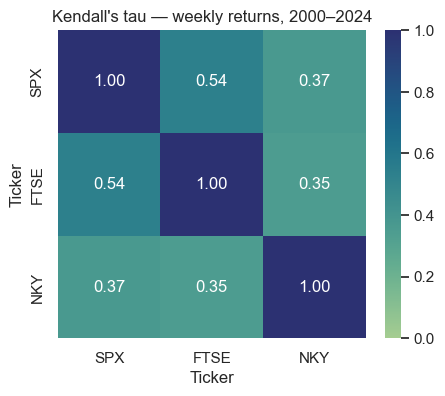

In [3]:
for m in ("pearson", "spearman", "kendall"):
    print(f"\n{m.capitalize()}")
    print(ret.corr(method=m).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(ret.corr(method="kendall"), annot=True, fmt=".2f",
            cmap="crest", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Kendall's tau — weekly returns, 2000–2024");

## 3 · Pseudo-observations: stripping the marginals

Sklar's theorem says any joint distribution splits into marginals + a copula.
To *see* the copula, replace each return by its normalised rank
$u_i = \operatorname{rank}(x_i)/(n+1)$ — the empirical probability integral
transform (statsmodels' `ECDF` gives the same map up to the $n+1$ scaling).
The result lives on the unit square: uniform margins by construction, so any
structure left is pure dependence. Watch the corners.

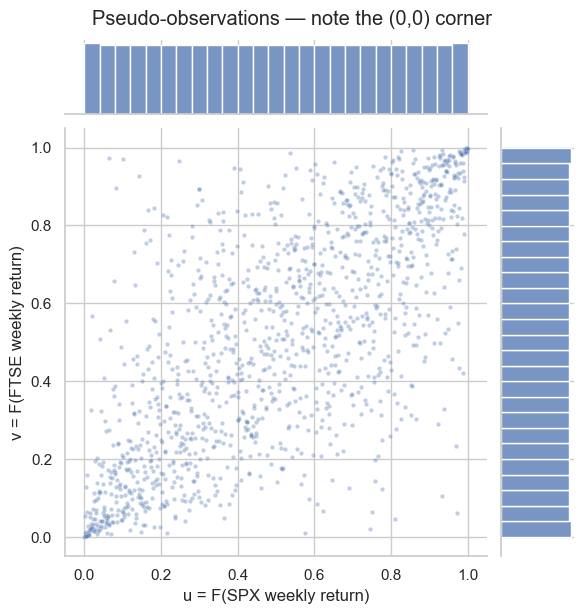

In [4]:
def pseudo_obs(x):
    return stats.rankdata(x) / (len(x) + 1)

U = pd.DataFrame({c: pseudo_obs(ret[c].values) for c in ret.columns},
                 index=ret.index)

# sanity check: this is just the ECDF rescaled by n/(n+1)
ecdf = ECDF(ret["SPX"].values)
assert np.allclose(U["SPX"], ecdf(ret["SPX"].values) * len(ret) / (len(ret) + 1))

g = sns.jointplot(x=U["SPX"], y=U["FTSE"], kind="scatter", s=10, alpha=0.35,
                  marginal_kws=dict(bins=25))
g.set_axis_labels("u = F(SPX weekly return)", "v = F(FTSE weekly return)")
g.figure.suptitle("Pseudo-observations — note the (0,0) corner", y=1.02);

## 4 · The Gaussian copula

The Gaussian copula is what you implicitly assume whenever you describe joint
behaviour with a correlation matrix alone. Fit it by mapping the pseudo-obs
through the standard normal quantile function ("normal scores") and taking
their correlation. Its fatal property: **zero tail dependence** — under a
Gaussian copula, the probability that both markets are in their worst q%
*given* one of them is, goes to zero as q → 0, for any ρ < 1. Joint crashes
are assumed away by construction.

In [5]:
Z = stats.norm.ppf(U)                      # normal scores
rho_gauss = pd.DataFrame(np.corrcoef(Z, rowvar=False),
                         index=U.columns, columns=U.columns)
print("Gaussian-copula correlation (normal scores):")
print(rho_gauss.round(3))

Gaussian-copula correlation (normal scores):
        SPX   FTSE    NKY
SPX   1.000  0.745  0.549
FTSE  0.745  1.000  0.527
NKY   0.549  0.527  1.000


## 5 · The Student-t copula, fitted by MLE

The t copula adds one parameter — degrees of freedom ν — and that single knob
buys tail dependence. We set ρ by Kendall's τ inversion
($\rho = \sin(\pi\tau/2)$, valid for all elliptical copulas) and profile the
likelihood over a ν grid from 2 to 30 for the SPX–FTSE pair.

Kendall tau = 0.536  ->  rho = 0.746
fitted df   = 3.5
log-lik: t copula 577.9  vs  Gaussian 526.8


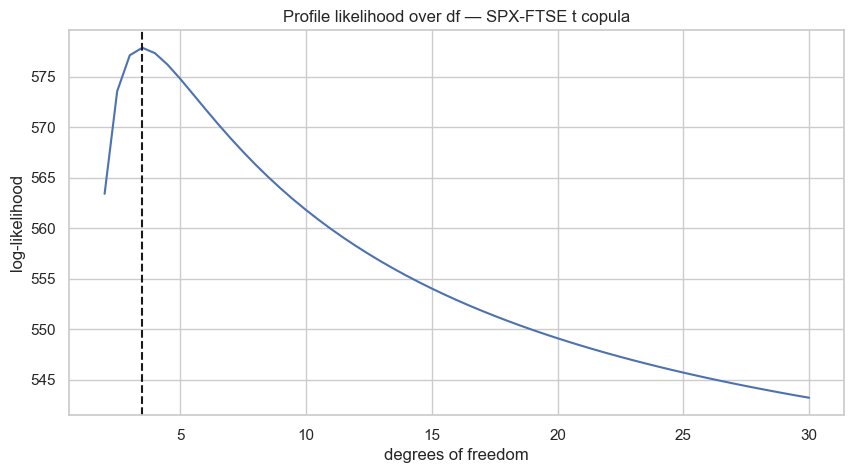

In [6]:
def t_copula_loglik(u, v, rho, df):
    x, y = stats.t.ppf(u, df), stats.t.ppf(v, df)
    det  = 1 - rho**2
    quad = (x**2 - 2*rho*x*y + y**2) / det
    ll = (gammaln((df+2)/2) + gammaln(df/2) - 2*gammaln((df+1)/2)
          - 0.5*np.log(det)
          - (df+2)/2 * np.log1p(quad/df)
          + (df+1)/2 * (np.log1p(x**2/df) + np.log1p(y**2/df)))
    return ll.sum()

def gauss_copula_loglik(u, v, rho):
    x, y = stats.norm.ppf(u), stats.norm.ppf(v)
    det  = 1 - rho**2
    ll = -0.5*np.log(det) - (rho**2*(x**2+y**2) - 2*rho*x*y) / (2*det)
    return ll.sum()

tau  = ret["SPX"].corr(ret["FTSE"], method="kendall")
rho  = np.sin(np.pi * tau / 2)                 # tau inversion
grid = np.arange(2.0, 30.5, 0.5)
ll   = np.array([t_copula_loglik(U["SPX"], U["FTSE"], rho, df) for df in grid])
df_hat = grid[ll.argmax()]

print(f"Kendall tau = {tau:.3f}  ->  rho = {rho:.3f}")
print(f"fitted df   = {df_hat:.1f}")
print(f"log-lik: t copula {ll.max():.1f}  vs  Gaussian "
      f"{gauss_copula_loglik(U['SPX'], U['FTSE'], rho_gauss.loc['SPX','FTSE']):.1f}")

plt.plot(grid, ll); plt.axvline(df_hat, ls="--", c="k")
plt.xlabel("degrees of freedom"); plt.ylabel("log-likelihood")
plt.title("Profile likelihood over df — SPX-FTSE t copula");

## 6 · Tail dependence: the empirical verdict

Lower-tail dependence at level q is
$\hat\lambda(q) = P(u \le q,\ v \le q)/q$ — the chance both markets are in
their worst q% weeks, relative to the q you'd get under independence-scaling.
Compare three answers per pair: the data, the fitted Gaussian copula
($C_\rho(q,q)/q$, which → 0 as q → 0), and the t copula's closed-form limit

$$\lambda_L = 2\, t_{\nu+1}\!\Big(-\sqrt{\tfrac{(\nu+1)(1-\rho)}{1+\rho}}\Big).$$

In [7]:
def bvn_cdf(a, rho, n=8001):
    z = np.linspace(-9.0, a, n)
    inner = stats.norm.cdf((a - rho*z) / np.sqrt(1 - rho**2))
    return np.trapezoid(inner * stats.norm.pdf(z), z)

def t_lambda(rho, df):
    return 2 * stats.t.cdf(-np.sqrt((df+1)*(1-rho)/(1+rho)), df=df+1)

pairs = [("SPX", "FTSE"), ("SPX", "NKY"), ("FTSE", "NKY")]
print(f"{'pair':<10}{'q':>5}{'empirical':>11}{'Gaussian':>10}{'t-copula':>10}")
for a, b in pairs:
    rho_g = rho_gauss.loc[a, b]
    rho_p = np.sin(np.pi * ret[a].corr(ret[b], method='kendall') / 2)
    lam   = t_lambda(rho_p, df_hat)
    for q in (0.01, 0.05, 0.10):
        emp = ((U[a] <= q) & (U[b] <= q)).mean() / q
        gau = bvn_cdf(stats.norm.ppf(q), rho_g) / q
        print(f"{a}-{b:<6}{q:>5.0%}{emp:>11.3f}{gau:>10.3f}{lam:>10.3f}")

pair          q  empirical  Gaussian  t-copula
SPX-FTSE     1%      0.614     0.311     0.459
SPX-FTSE     5%      0.553     0.435     0.459
SPX-FTSE    10%      0.553     0.508     0.459
SPX-NKY      1%      0.307     0.156     0.309
SPX-NKY      5%      0.369     0.275     0.309
SPX-NKY     10%      0.422     0.356     0.309
FTSE-NKY      1%      0.230     0.143     0.292
FTSE-NKY      5%      0.323     0.260     0.292
FTSE-NKY     10%      0.376     0.341     0.292


## 7 · Conditional crash probabilities

The same idea, phrased the way a risk committee asks it: *given the S&P has a
worst-decile week, what is the chance the FTSE does too?* Under independence
the answer would be 10%.

In [8]:
thr = 0.10
for a, b in pairs:
    mask = U[a] <= thr
    p = (mask & (U[b] <= thr)).sum() / mask.sum()
    print(f"P({b} worst decile | {a} worst decile) = {p:.1%}   (independence: 10.0%)")

P(FTSE worst decile | SPX worst decile) = 55.4%   (independence: 10.0%)
P(NKY worst decile | SPX worst decile) = 42.3%   (independence: 10.0%)
P(NKY worst decile | FTSE worst decile) = 37.7%   (independence: 10.0%)


## Takeaways

- Correlation compresses dependence into one number; the copula keeps the whole
  structure — and the corners are where the risk is.
- Pseudo-observations (ranks / PIT) let you study dependence without committing
  to any marginal model.
- The Gaussian copula has λ = 0: joint crashes become *vanishingly* rare as you
  go further into the tail — 2008 (and the Li 2000 CDO machinery built on it)
  is the canonical counter-example.
- One extra parameter fixes most of it: a Student-t copula with a modest df
  reproduces the joint-crash clustering the data actually shows.
- Weekly resampling matters for global assets: Tokyo's close leads New York's,
  and daily correlations silently absorb that offset.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*